# AI-Powered Banking Customer Analytics System

This notebook covers Python data analysis, machine learning, deep learning, model export, and Power BI CSV export. SQL work for the project is handled in SQL Server Management Studio using `banking_customer_analytics_sql_server.sql`.


## 1. Install Required Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn plotly joblib tensorflow

## 2. Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

## 3. Create Project Folders

In [2]:
Path('data').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)
Path('database').mkdir(exist_ok=True)
Path('powerbi_exports').mkdir(exist_ok=True)

## 4. Load Banking Customer Dataset

Place your dataset at `data/bank_customers.csv`.

Recommended Kaggle dataset columns: `RowNumber`, `CustomerId`, `Surname`, `CreditScore`, `Geography`, `Gender`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`, `Exited`.

In [3]:
customer_df = pd.read_csv("Churn_Modelling.csv")
customer_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 5. Basic Data Analysis

In [4]:
print('Shape:', customer_df.shape)
print(customer_df.info())
print('\nMissing values:')
print(customer_df.isnull().sum())
customer_df.describe()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Missing values:
RowNumber          0
CustomerId         0
Surname    

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


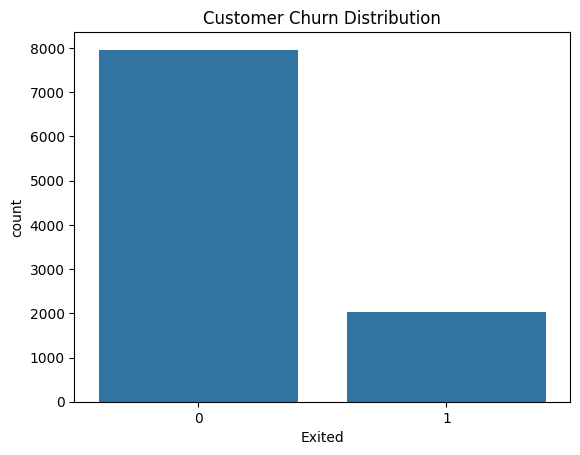

In [5]:
sns.countplot(data=customer_df, x='Exited')
plt.title('Customer Churn Distribution')
plt.show()

## 6. Data Cleaning Helper

In [8]:
def clean_data(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)

    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = df[column].fillna(df[column].mode()[0])
        else:
            df[column] = df[column].fillna(df[column].median())

    return df

## 7. Machine Learning: Churn Prediction

In [9]:
df = clean_data(customer_df)

for column in ['RowNumber', 'CustomerId', 'Surname']:
    if column in df.columns:
        df.drop(columns=[column], inplace=True)

target_column = 'Exited'
encoders = {}

for column in df.select_dtypes(include=['object']).columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

X = df.drop(columns=[target_column])
y = df[target_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
churn_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

churn_model.fit(X_train, y_train)
churn_predictions = churn_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, churn_predictions))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, churn_predictions))
print('\nClassification Report:')
print(classification_report(y_test, churn_predictions))

Accuracy: 0.857

Confusion Matrix:
[[1538   55]
 [ 231  176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1593
           1       0.76      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [11]:
joblib.dump(
    {
        'model': churn_model,
        'scaler': scaler,
        'encoders': encoders,
        'features': list(X.columns)
    },
    'models/churn_model.pkl'
)

print('Churn model saved.')

Churn model saved.


## Churn Model Feature Importance


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": churn_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance for Churn Prediction")
plt.show()


## 08. Machine Learning: Customer Segmentation

In [12]:
segment_df = clean_data(customer_df)

for column in ['RowNumber', 'CustomerId', 'Surname', 'Exited']:
    if column in segment_df.columns:
        segment_df.drop(columns=[column], inplace=True)

segment_encoders = {}

for column in segment_df.select_dtypes(include=['object']).columns:
    encoder = LabelEncoder()
    segment_df[column] = encoder.fit_transform(segment_df[column])
    segment_encoders[column] = encoder

segment_scaler = StandardScaler()
segment_scaled = segment_scaler.fit_transform(segment_df)

kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_segments = kmeans_model.fit_predict(segment_scaled)

print('Silhouette Score:', silhouette_score(segment_scaled, customer_segments))

customer_df['CustomerSegment'] = customer_segments
customer_df.head()

Silhouette Score: 0.09060694648462393


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CustomerSegment
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1


In [13]:
joblib.dump(
    {
        'model': kmeans_model,
        'scaler': segment_scaler,
        'encoders': segment_encoders,
        'features': list(segment_df.columns)
    },
    'models/segmentation_model.pkl'
)

segments_table = pd.DataFrame({
    'customer_id': customer_df['CustomerId'] if 'CustomerId' in customer_df.columns else customer_df.index + 1,
    'segment_number': customer_df['CustomerSegment'],
    'segment_name': customer_df['CustomerSegment'].apply(lambda value: f'Segment {value}'),
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
})

print('Segmentation model saved and segment table prepared for Power BI / SQL Server import.')
segments_table.head()


Segmentation model and SQL segment table saved.


,customer_id,segment_number,segment_name,created_date
0,15634602,1,Segment 1,2026-05-16 21:06:50
1,15647311,0,Segment 0,2026-05-16 21:06:50
2,15619304,2,Segment 2,2026-05-16 21:06:50
3,15701354,0,Segment 0,2026-05-16 21:06:50
4,15737888,1,Segment 1,2026-05-16 21:06:50


## 09. Create Sample Transaction Data

In [14]:
np.random.seed(42)

customer_ids = customer_df['CustomerId'] if 'CustomerId' in customer_df.columns else range(1, len(customer_df) + 1)

transaction_df = pd.DataFrame({
    'transaction_id': range(1, 5001),
    'customer_id': np.random.choice(customer_ids, 5000),
    'transaction_date': pd.date_range(start='2024-01-01', periods=5000, freq='h'),
    'transaction_type': np.random.choice(['Deposit', 'Withdrawal', 'Transfer', 'Payment'], 5000),
    'amount': np.random.exponential(scale=5000, size=5000).round(2),
    'transaction_frequency': np.random.randint(1, 50, 5000),
    'average_transaction_amount': np.random.exponential(scale=4000, size=5000).round(2),
    'account_age_days': np.random.randint(30, 3000, 5000),
    'merchant_category': np.random.choice(['Retail', 'Travel', 'Food', 'Bills', 'Online'], 5000),
    'location': np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai'], 5000)
})

transaction_df.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_frequency,average_transaction_amount,account_age_days,merchant_category,location
0,1,15706268,2024-01-01 00:00:00,Payment,600.86,40,307.77,1752,Travel,Chennai
1,2,15807663,2024-01-01 01:00:00,Withdrawal,2607.46,33,2629.24,449,Online,Chennai
2,3,15573851,2024-01-01 02:00:00,Withdrawal,3318.65,25,9043.60,2863,Travel,Mumbai
3,4,15681075,2024-01-01 03:00:00,Transfer,3891.64,36,833.87,162,Food,Chennai
4,5,15596647,2024-01-01 04:00:00,Payment,8528.66,24,1609.01,2091,Bills,Mumbai


## 10. Machine Learning: Fraud Detection With Isolation Forest

In [15]:
fraud_features = [
    'amount',
    'transaction_frequency',
    'average_transaction_amount',
    'account_age_days'
]

fraud_X = transaction_df[fraud_features].copy()
fraud_X = fraud_X.fillna(fraud_X.median())

fraud_scaler = StandardScaler()
fraud_X_scaled = fraud_scaler.fit_transform(fraud_X)

fraud_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

fraud_prediction = fraud_model.fit_predict(fraud_X_scaled)

transaction_df['fraud_status'] = [
    'Suspicious' if value == -1 else 'Normal'
    for value in fraud_prediction
]

transaction_df['fraud_status'].value_counts()

fraud_status
Normal        4850
Suspicious     150
Name: count, dtype: int64

In [16]:
joblib.dump(
    {
        'model': fraud_model,
        'scaler': fraud_scaler,
        'features': fraud_features
    },
    'models/fraud_model.pkl'
)

print('Fraud model saved and transaction table prepared for Power BI / SQL Server import.')


Fraud model and transactions table saved.


## 11. Deep Learning: Fraud Detection Autoencoder

In [17]:
X_train_dl, X_test_dl = train_test_split(
    fraud_X_scaled,
    test_size=0.2,
    random_state=42
)

input_dim = X_train_dl.shape[1]
input_layer = Input(shape=(input_dim,))

encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_train_dl,
    X_train_dl,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.8761 - val_loss: 0.6638
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4320 - val_loss: 0.2562
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1481 - val_loss: 0.0812
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0515 - val_loss: 0.0380
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0283 - val_loss: 0.0240
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0192 - val_loss: 0.0169
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0141 - val_loss: 0.0123
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0104 - val_loss: 0.0094
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0081 - val_loss: 0.0072
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Autoencoder fraud threshold: 0.0019993963113378727


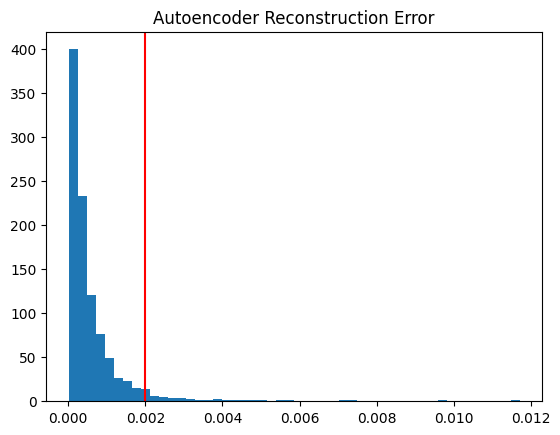

Deep learning fraud model saved.


In [18]:
reconstructed = autoencoder.predict(X_test_dl)
reconstruction_error = np.mean(np.square(X_test_dl - reconstructed), axis=1)
threshold = np.percentile(reconstruction_error, 95)

print('Autoencoder fraud threshold:', threshold)

plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, color='red')
plt.title('Autoencoder Reconstruction Error')
plt.show()

autoencoder.save('models/dl_fraud_autoencoder.keras')

joblib.dump(
    {
        'scaler': fraud_scaler,
        'features': fraud_features,
        'threshold': threshold
    },
    'models/dl_fraud_scaler.pkl'
)

print('Deep learning fraud model saved.')

## 12. Product Recommendation Function

In [19]:
def recommend_products(customer):
    recommendations = []

    if customer['Balance'] > 100000:
        recommendations.append('Premium Savings Account')

    if customer['CreditScore'] > 700 and customer['EstimatedSalary'] > 50000:
        recommendations.append('Credit Card Upgrade')

    if customer['Age'] > 30 and customer['Tenure'] > 3:
        recommendations.append('Home Loan Offer')

    if customer['Balance'] < 10000:
        recommendations.append('Financial Planning Assistance')

    if not recommendations:
        recommendations.append('Standard Savings Account')

    return recommendations

## 13. Test Single Customer Prediction

In [20]:
sample_customer = customer_df.iloc[0]
model_bundle = joblib.load('models/churn_model.pkl')

input_data = pd.DataFrame([{
    'CreditScore': sample_customer['CreditScore'],
    'Geography': sample_customer['Geography'],
    'Gender': sample_customer['Gender'],
    'Age': sample_customer['Age'],
    'Tenure': sample_customer['Tenure'],
    'Balance': sample_customer['Balance'],
    'NumOfProducts': sample_customer['NumOfProducts'],
    'HasCrCard': sample_customer['HasCrCard'],
    'IsActiveMember': sample_customer['IsActiveMember'],
    'EstimatedSalary': sample_customer['EstimatedSalary']
}])

for column, encoder in model_bundle['encoders'].items():
    if column in input_data.columns:
        input_data[column] = encoder.transform(input_data[column])

input_data = input_data[model_bundle['features']]
input_scaled = model_bundle['scaler'].transform(input_data)

prediction = model_bundle['model'].predict(input_scaled)[0]
probability = model_bundle['model'].predict_proba(input_scaled)[0][1]
churn_risk = 'High Risk' if prediction == 1 else 'Low Risk'

customer_id = int(sample_customer['CustomerId']) if 'CustomerId' in customer_df.columns else 1

print('Customer ID:', customer_id)
print('Churn Risk:', churn_risk)
print('Churn Probability:', round(float(probability), 4))
print('Recommendations:', recommend_products(sample_customer))

Customer ID: 15634602
Churn Risk: High Risk
Churn Probability: 0.71
Recommendations: ['Financial Planning Assistance']


## 14. Prepare Prediction And Recommendation Tables

In [ ]:
model_bundle = joblib.load("models/churn_model.pkl")

all_customer_input = customer_df[[
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]].copy()

for column, encoder in model_bundle["encoders"].items():
    if column in all_customer_input.columns:
        all_customer_input[column] = encoder.transform(all_customer_input[column])

all_customer_input = all_customer_input[model_bundle["features"]]
all_customer_scaled = model_bundle["scaler"].transform(all_customer_input)

all_predictions = model_bundle["model"].predict(all_customer_scaled)
all_probabilities = model_bundle["model"].predict_proba(all_customer_scaled)[:, 1]

prediction_table = pd.DataFrame({
    "customer_id": customer_df["CustomerId"],
    "churn_risk": ["High Risk" if value == 1 else "Low Risk" for value in all_predictions],
    "churn_probability": all_probabilities.round(4),
    "prediction_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
})

recommendation_rows = []
for _, customer in customer_df.iterrows():
    for product in recommend_products(customer):
        recommendation_rows.append({
            "customer_id": customer["CustomerId"],
            "recommended_product": product,
            "recommendation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        })

recommendation_table = pd.DataFrame(recommendation_rows)

print("Prediction rows:", len(prediction_table))
print("Recommendation rows:", len(recommendation_table))
prediction_table.head()


## SQL Server / SSMS Import Note

This notebook exports CSV files. For SQL Server, import `Churn_Modelling.csv` and the generated CSV files using SSMS `Tasks > Import Flat File`, or use the SQL script `banking_customer_analytics_sql_server.sql` for schema, views, and analysis queries.


## 15. Export CSV Files For Power BI

In [22]:
customer_df.to_csv('powerbi_exports/customers.csv', index=False)
transaction_df.to_csv('powerbi_exports/transactions.csv', index=False)
segments_table.to_csv('powerbi_exports/customer_segments.csv', index=False)
prediction_table.to_csv('powerbi_exports/churn_predictions.csv', index=False)
recommendation_table.to_csv('powerbi_exports/product_recommendations.csv', index=False)

print('CSV files exported for Power BI.')

CSV files exported for Power BI.
